In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
scada = pd.read_csv("data/processed/scada_clean.csv")

In [30]:
# feature engineering part
# 1) wind power density
scada["wind_power_density"] = 0.5 * 1.225 * scada["wind_speed_ms"]**3 # W/m^2

# 2) actual output / maximu output
scada["capacity_factor"] = scada["active_power_kw"] / 2050

# 3) efficiency (how close actual power is to theoretical)
theo = scada["theoretical_power_kw"]
actual = scada["active_power_kw"]
scada["power_efficiency"] = (actual / theo).where(theo > 10)

# 4) wind direction components
scada["dir_sin"] = np.sin(np.radians(scada["wind_direction_deg"]))
scada["dir_cos"] = np.cos(np.radians(scada["wind_direction_deg"]))

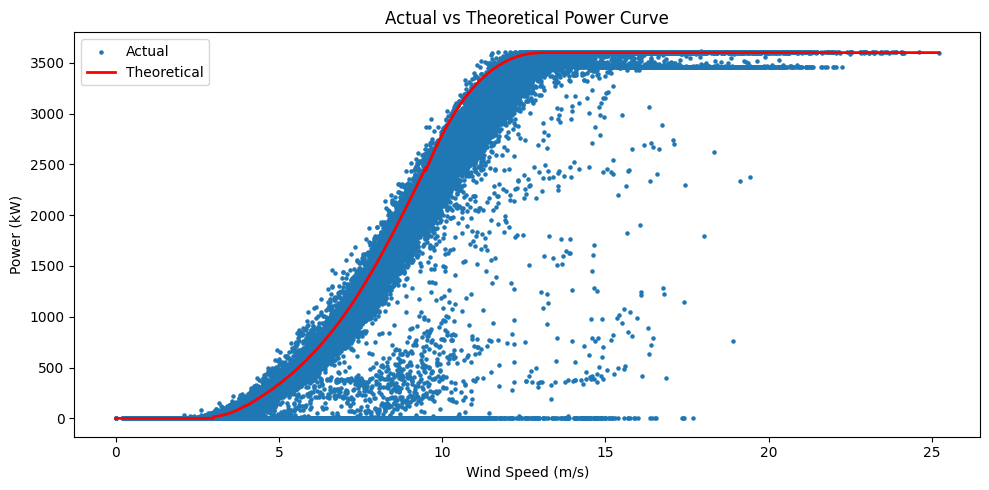

In [31]:
# power curve - actual vs theoretical
theo_plot = scada[["wind_speed_ms", "theoretical_power_kw"]].dropna().sort_values("wind_speed_ms")

fig, ax = plt.subplots(figsize=(10, 5))

# the actual scatter
ax.scatter(scada["wind_speed_ms"], scada["active_power_kw"], s=5, label="Actual")

# theoretical line
ax.plot(theo_plot["wind_speed_ms"], theo_plot["theoretical_power_kw"], color="red", linewidth=2, label="Theoretical")
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Power (kW)")
ax.set_title("Actual vs Theoretical Power Curve")
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/figures/actual_vs_theoretical.png", dpi=120)
plt.show()

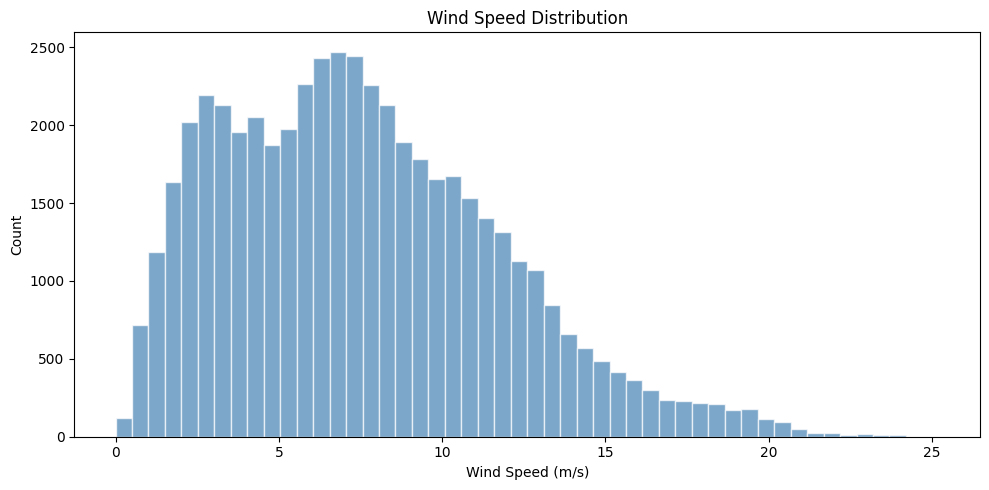

In [32]:
# wind speed distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scada["wind_speed_ms"].dropna(), bins=50,
        color="steelblue", alpha=0.7, edgecolor="white")
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Count")
ax.set_title("Wind Speed Distribution")
plt.tight_layout()
plt.savefig("data/processed/figures/wind_distribution.png", dpi=120)
plt.show()

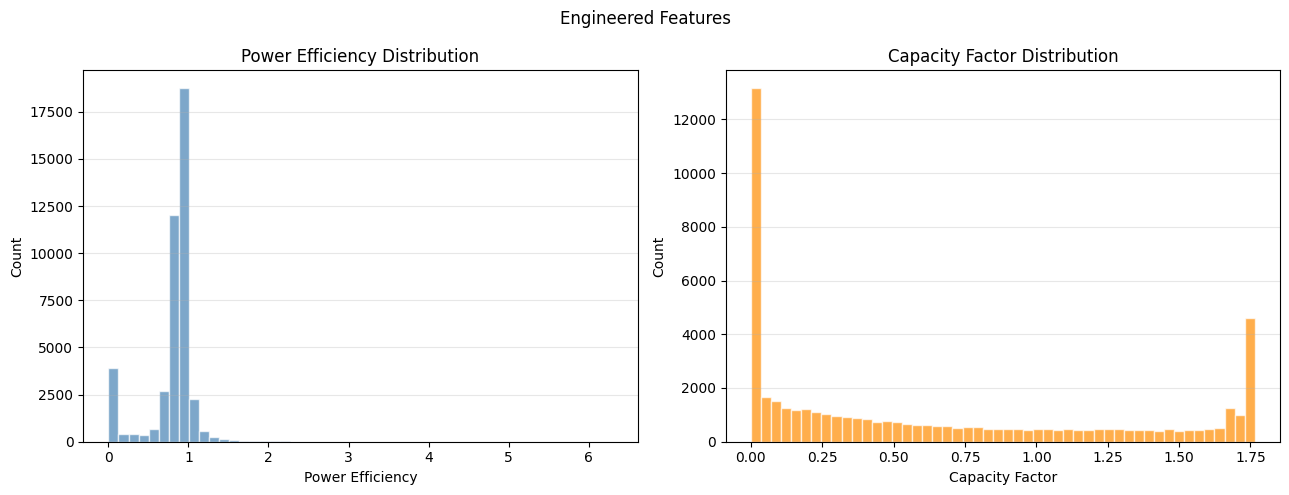

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Engineered Features")

axes[0].hist(scada["power_efficiency"].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.7)
axes[0].set_xlabel("Power Efficiency")
axes[0].set_ylabel("Count")
axes[0].set_title("Power Efficiency Distribution")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(scada["capacity_factor"].dropna(), bins=50, color="darkorange", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("Capacity Factor")
axes[1].set_ylabel("Count")
axes[1].set_title("Capacity Factor Distribution")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# export for ML
scada.to_csv("data/processed/scada_features.csv", index=False)